# Sales Data Analysis

A end-to-end exploratory data analysis of a retail sales dataset, focused on uncovering
trends in **when**, **where**, and **what** customers buy, along with which products are
most often purchased together.

## Objectives
- Identify the best-performing months, days, and hours for sales
- Find which city generates the most orders
- Determine the best-selling and highest-revenue products
- Discover which products are frequently bought together (market basket analysis)
- Segment products by revenue contribution using ABC / Pareto analysis

## Dataset
The dataset (`data/sales_data.ftr`) contains individual order line items, including order ID,
product, quantity ordered, price, order date, and purchase address.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx

from itertools import combinations
from collections import Counter
from mlxtend.frequent_patterns import apriori, association_rules

import warnings

warnings.filterwarnings("ignore")

# All dependencies are listed in requirements.txt -> pip install -r requirements.txt

## 2. Load Dataset

In [2]:
data = pd.read_feather(r'data/sales_data.ftr')

## 3. Data Inspection

In [3]:
data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [4]:
data.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

## 4. Data Cleaning

- Drop fully empty rows
- Drop duplicate rows
- Remove stray header rows that got mixed into the data (a common artifact when several
  raw CSV exports are concatenated together, each carrying its own header row)

In [5]:
data = data.dropna(how='all')
data = data.drop_duplicates()

## 5. Feature Engineering

Extract the fields needed for the analysis below: order month, city, total sale value,
and order hour/day of week.

In [6]:
def extract_month(date):
    """Extract the month (as a string) from a 'M/D/YYYY H:MM' date string."""
    return date.split('/')[0]

data['Month'] = data['Order Date'].apply(extract_month)

# A few rows are stray header rows ("Order Date") left over from the raw data; drop them
data = data[data['Month'] != 'Order Date']

In [7]:
data['Month'] = data['Month'].astype(int)
data['Quantity Ordered'] = data['Quantity Ordered'].astype(int)
data['Price Each'] = data['Price Each'].astype(float)

data.dtypes

Order ID                str
Product                 str
Quantity Ordered      int64
Price Each          float64
Order Date              str
Purchase Address        str
Month                 int64
dtype: object

In [8]:
data['Sales'] = data['Quantity Ordered'] * data['Price Each']

In [9]:
def extract_city(address):
    """Extract the city name from a 'Street, City, State ZIP' address string."""
    return address.split(',')[1]

data['City'] = data['Purchase Address'].apply(extract_city)

# Alternative one-liner:
# data['City'] = data['Purchase Address'].str.split(',').str.get(1)

In [10]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Hour'] = data['Order Date'].dt.hour
data['Day'] = data['Order Date'].dt.day_name()

data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour,Day
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,23.90,Dallas,8,Friday
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,99.99,Boston,22,Sunday
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,14,Friday
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,11.99,Los Angeles,14,Friday
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,11.99,Los Angeles,9,Tuesday


## 6. Exploratory Data Analysis (EDA)

### 6.1 Which month has the highest sales?

In [11]:
data.groupby('Month')['Sales'].sum()

Month
1     1821413.16
2     2200078.08
3     2804973.35
4     3389217.98
5     3150616.23
6     2576280.15
7     2646461.32
8     2241083.37
9     2094465.69
10    3734777.86
11    3197875.05
12    4608295.70
Name: Sales, dtype: float64

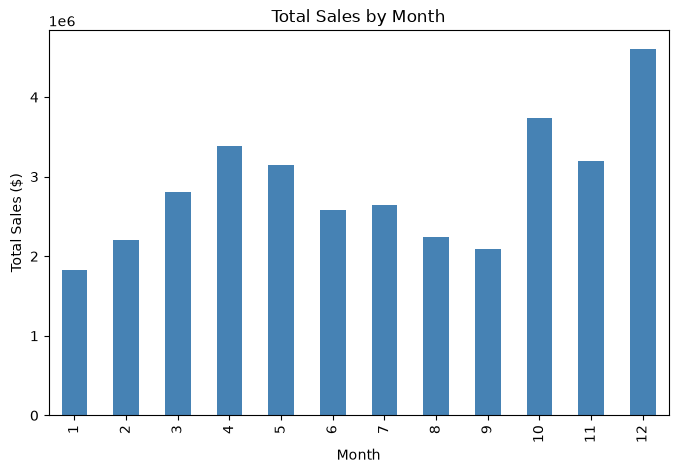

In [12]:
data.groupby('Month')['Sales'].sum().plot(kind='bar', figsize=(8, 5), color='steelblue')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.show()

### 6.2 Which city has the most orders?

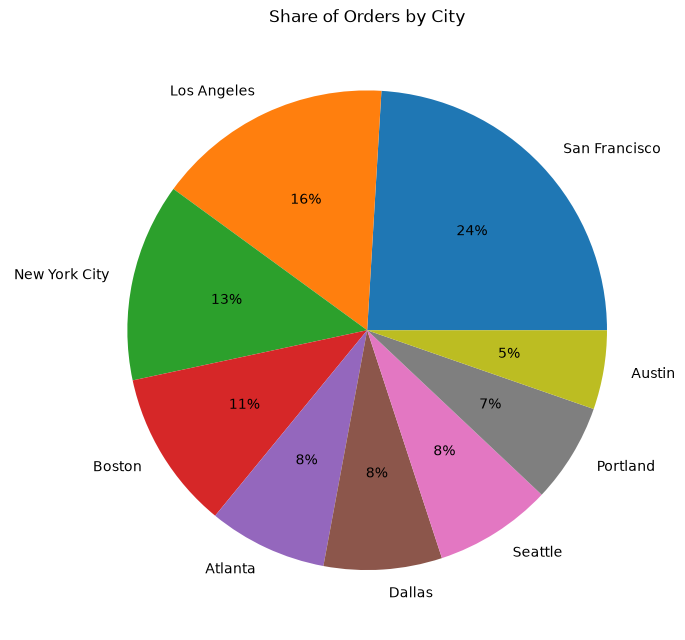

In [13]:
data['City'].value_counts().plot(
    kind='pie', autopct='%1.0f%%', figsize=(7, 7), ylabel=''
)
plt.title('Share of Orders by City')
plt.tight_layout()
plt.show()

### 6.3 Which products sell the most, and why?

In [14]:
product_df = data.groupby('Product').agg({'Quantity Ordered': 'sum', 'Price Each': 'mean'})
product_df = product_df.reset_index()
product_df

,Product,Quantity Ordered,Price Each
0,20in Monitor,4126,109.99
1,27in 4K Gaming Monitor,6239,389.99
2,27in FHD Monitor,7541,149.99
3,34in Ultrawide Monitor,6192,379.99
4,AA Batteries (4-pack),27615,3.84
5,AAA Batteries (4-pack),30986,2.99
6,Apple Airpods Headphones,15637,150.00
7,Bose SoundSport Headphones,13430,99.99
8,Flatscreen TV,4813,300.00
9,Google Phone,5529,600.00


In [15]:
norm = mcolors.Normalize(
    vmin=min(product_df['Quantity Ordered']),
    vmax=max(product_df['Quantity Ordered'])
)
cmap = plt.cm.RdYlGn
colors = [cmap(norm(v)) for v in product_df['Quantity Ordered']]

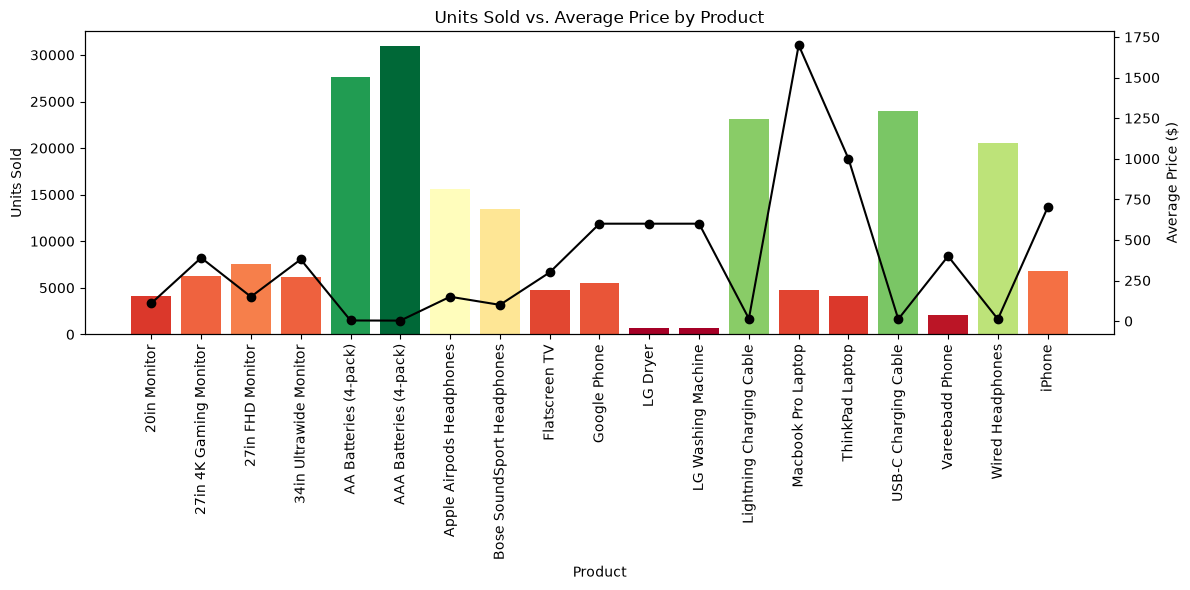

In [16]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.bar(product_df['Product'], product_df['Quantity Ordered'], color=colors)
ax2.plot(product_df['Product'], product_df['Price Each'], color='black', marker='o')

ax1.set_xticklabels(product_df['Product'].values, rotation='vertical')
ax1.set_xlabel('Product')
ax1.set_ylabel('Units Sold')
ax2.set_ylabel('Average Price ($)')
ax1.set_title('Units Sold vs. Average Price by Product')

plt.tight_layout()
plt.show()

# Products sell more when they're cheaper - price and quantity ordered are inversely related

### 6.4 Monthly trend of the top 5 best-selling products

In [17]:
most_sold_products = data['Product'].value_counts()[0:5].index

In [18]:
most_sold_products_df = data[data['Product'].isin(most_sold_products)]
most_sold_products_pivot = most_sold_products_df.groupby(['Month', 'Product']).size().unstack()
most_sold_products_pivot

Product,AA Batteries (4-pack),AAA Batteries (4-pack),Lightning Charging Cable,USB-C Charging Cable,Wired Headphones
Month,,,,,
1,1037,1084,1069,1171,1004
2,1274,1320,1393,1511,1179
3,1672,1645,1749,1766,1512
4,2062,1988,2197,2074,1888
5,1821,1888,1929,1879,1729
6,1540,1451,1560,1531,1334
7,1555,1554,1690,1667,1434
8,1357,1340,1354,1339,1191
9,1314,1281,1324,1451,1173


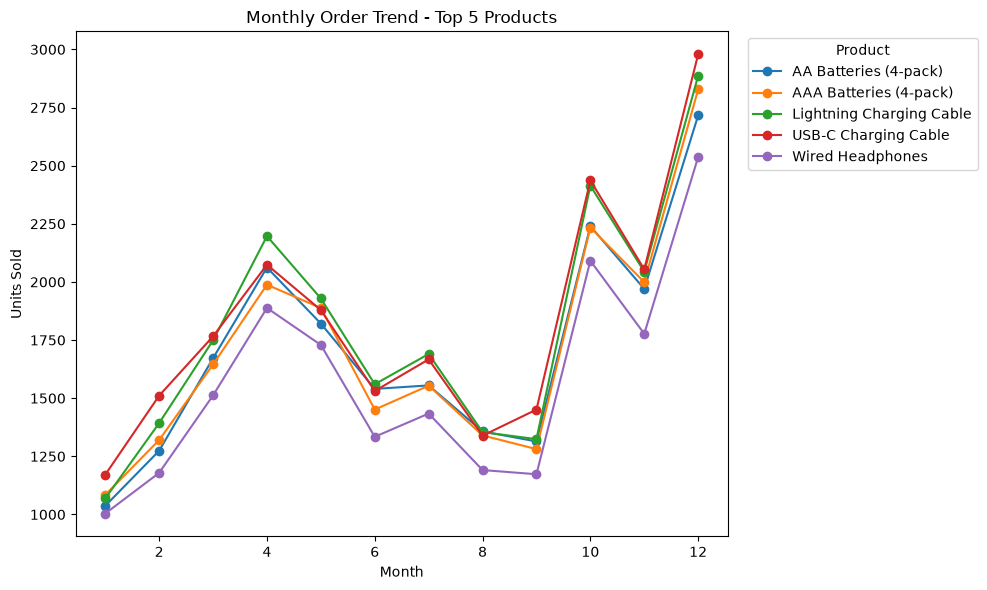

In [19]:
most_sold_products_pivot.plot(figsize=(10, 6), marker='o')
plt.title('Monthly Order Trend - Top 5 Products')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.legend(title='Product', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 6.5 Sales by hour of day

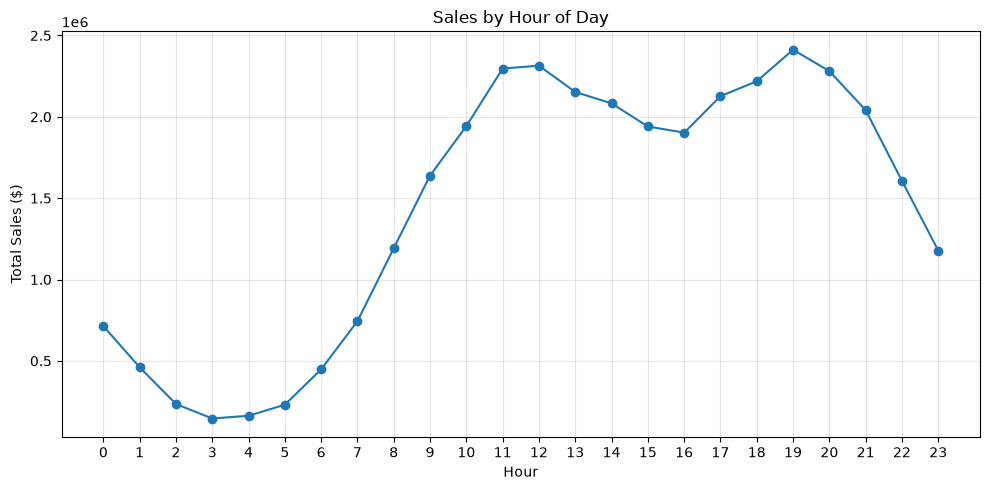

In [20]:
hourly_sales = data.groupby('Hour')['Sales'].sum()

plt.figure(figsize=(10, 5))
plt.plot(hourly_sales.index, hourly_sales.values, marker='o')
plt.title('Sales by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Total Sales ($)')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Useful for deciding when to run ads / staff support around peak shopping hours

### 6.6 Sales by day of week

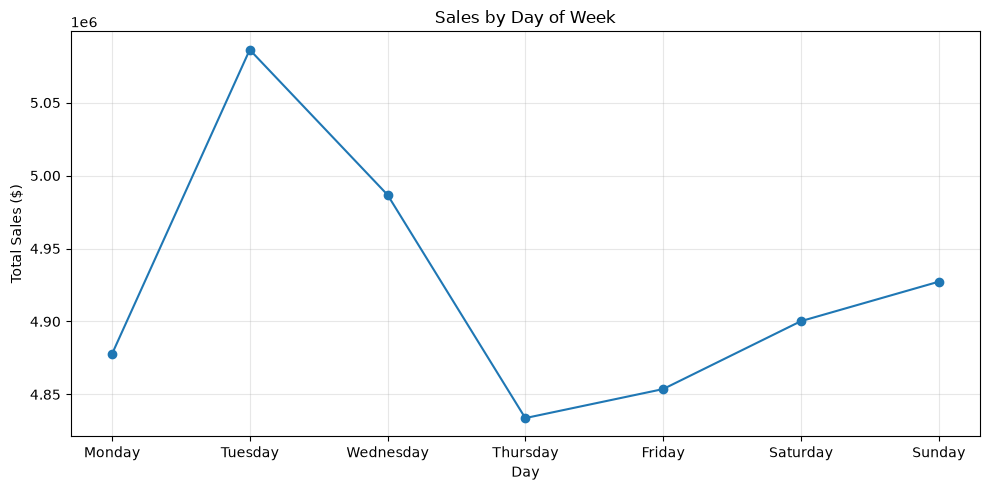

In [21]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales = data.groupby('Day')['Sales'].sum().reindex(days)

plt.figure(figsize=(10, 5))
plt.plot(daily_sales.index, daily_sales.values, marker='o')
plt.title('Sales by Day of Week')
plt.xlabel('Day')
plt.ylabel('Total Sales ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Market Basket Analysis

Which products tend to be bought together in the same order?

In [22]:
# Orders that contain more than one product line
duplicated_df = data[data['Order ID'].duplicated(keep=False)]

grouped_products = (
    duplicated_df.groupby('Order ID')['Product']
    .apply(lambda x: ','.join(x))
    .reset_index()
    .rename(columns={'Product': 'Grouped Products'})
)

orders_with_products = (
    duplicated_df.merge(grouped_products, how='left', on='Order ID')
    .drop_duplicates(subset=['Order ID'])
)
orders_with_products.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour,Day,Grouped Products
0,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,600.00,Los Angeles,14,Friday,"Google Phone,Wired Headphones"
2,176574,Google Phone,1,600.00,2019-04-03 19:42:00,"20 Hill St, Los Angeles, CA 90001",4,600.00,Los Angeles,19,Wednesday,"Google Phone,USB-C Charging Cable"
4,176586,AAA Batteries (4-pack),2,2.99,2019-04-10 17:00:00,"365 Center St, San Francisco, CA 94016",4,5.98,San Francisco,17,Wednesday,"AAA Batteries (4-pack),Google Phone"
6,176672,Lightning Charging Cable,1,14.95,2019-04-12 11:07:00,"778 Maple St, New York City, NY 10001",4,14.95,New York City,11,Friday,"Lightning Charging Cable,USB-C Charging Cable"
8,176681,Apple Airpods Headphones,1,150.00,2019-04-20 10:39:00,"331 Cherry St, Seattle, WA 98101",4,150.00,Seattle,10,Saturday,"Apple Airpods Headphones,ThinkPad Laptop"


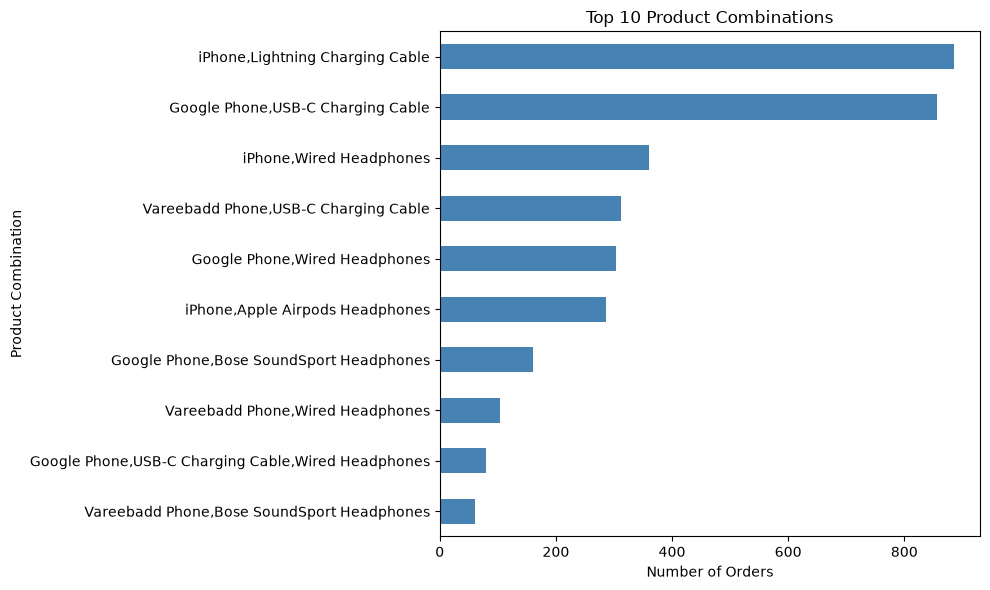

In [23]:
top10_combos = orders_with_products['Grouped Products'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top10_combos.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Product Combinations')
plt.xlabel('Number of Orders')
plt.ylabel('Product Combination')
plt.tight_layout()
plt.show()

**Co-purchase network** - a graph view of which product *pairs* appear together most often, regardless of the exact combination of products in the order.

In [24]:
pair_counter = Counter()

for products in orders_with_products['Grouped Products']:
    product_list = products.split(',')
    for pair in combinations(sorted(product_list), 2):
        pair_counter[pair] += 1

top_pairs = pair_counter.most_common(10)

G = nx.Graph()
for (p1, p2), weight in top_pairs:
    G.add_edge(p1, p2, weight=weight)

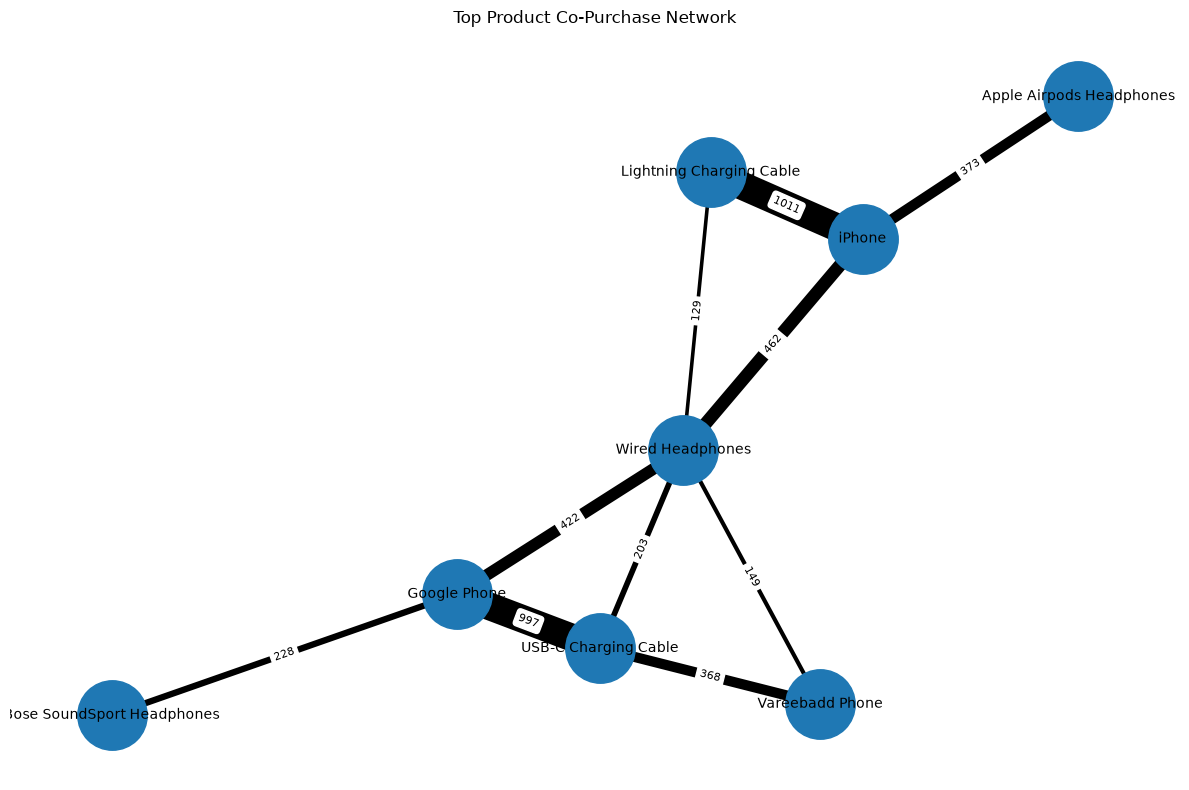

In [25]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)
weights = [G[u][v]['weight'] / 50 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=2500)
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, width=weights)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title('Top Product Co-Purchase Network')
plt.axis('off')
plt.tight_layout()
plt.show()

**Association rule mining** - a more rigorous version of the same question, using the *support / confidence / lift* metrics to quantify how strongly products are associated.

In [26]:
orders = data.groupby('Order ID')['Product'].count()
multi_item_orders = orders[orders > 1].index

basket = data[data['Order ID'].isin(multi_item_orders)]
basket = (
    basket.groupby(['Order ID', 'Product'])['Product']
    .count()
    .unstack(fill_value=0)
)
basket = (basket > 0).astype(int)

In [27]:
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)

# Keep only the columns relevant for interpretation
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

rules.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,support,confidence,lift
9,frozenset({iPhone}),frozenset({Lightning Charging Cable}),0.146969,0.542382,2.159170
8,frozenset({Lightning Charging Cable}),frozenset({iPhone}),0.146969,0.585069,2.159170
10,frozenset({Vareebadd Phone}),frozenset({USB-C Charging Cable}),0.053496,0.612313,2.084166
11,frozenset({USB-C Charging Cable}),frozenset({Vareebadd Phone}),0.053496,0.182088,2.084166
5,frozenset({USB-C Charging Cable}),frozenset({Google Phone}),0.144934,0.493320,2.078107
4,frozenset({Google Phone}),frozenset({USB-C Charging Cable}),0.144934,0.610533,2.078107
0,frozenset({iPhone}),frozenset({Apple Airpods Headphones}),0.054223,0.200107,1.486542
1,frozenset({Apple Airpods Headphones}),frozenset({iPhone}),0.054223,0.402808,1.486542
2,frozenset({Google Phone}),frozenset({Bose SoundSport Headphones}),0.033144,0.139620,1.253849
3,frozenset({Bose SoundSport Headphones}),frozenset({Google Phone}),0.033144,0.297650,1.253849


> **Insight:** Association Rule Mining revealed strong purchasing relationships between
> smartphones and their compatible charging accessories. Customers purchasing an iPhone
> were highly likely to also purchase a Lightning Charging Cable (Lift = 2.16), while
> Google Phone buyers frequently purchased USB-C Charging Cables (Lift = 2.08). These
> findings highlight valuable cross-selling and product bundling opportunities.

## 8. Revenue Analysis - ABC & Pareto

Rank products by revenue contribution and classify them into A/B/C tiers, following the
classic 80/15/5 rule used in inventory and revenue management.

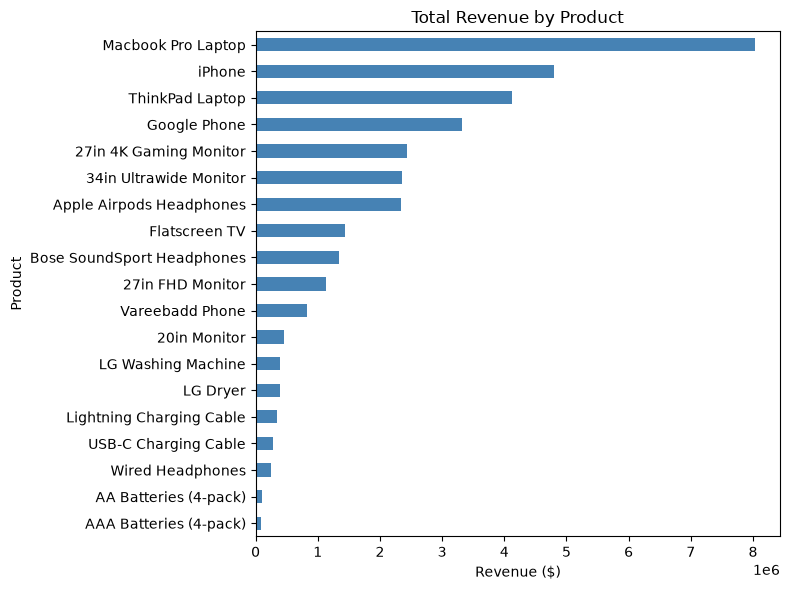

In [28]:
revenue_by_product = data.groupby('Product')['Sales'].sum().sort_values()
revenue_by_product.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Total Revenue by Product')
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.show()

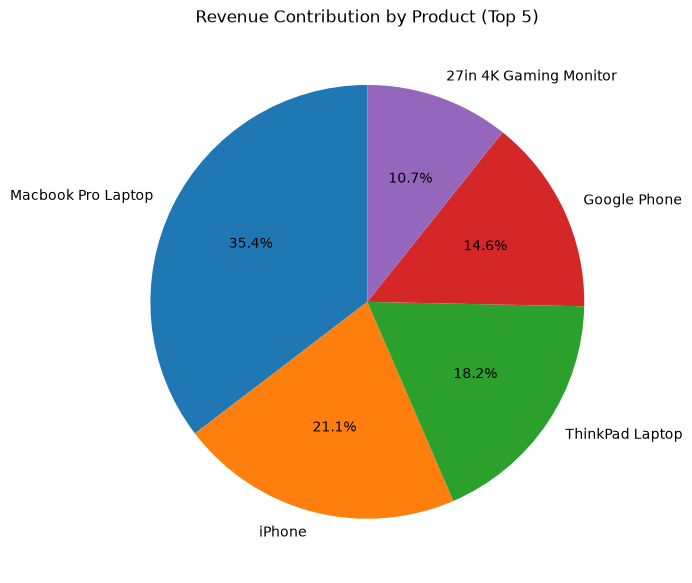

In [29]:
product_share = data.groupby('Product')['Sales'].sum().sort_values(ascending=False)
product_share = product_share / product_share.sum() * 100

top5_share = product_share.head(5)
plt.figure(figsize=(7, 7))
plt.pie(top5_share.values, labels=top5_share.index, autopct='%1.1f%%', startangle=90)
plt.title('Revenue Contribution by Product (Top 5)')
plt.tight_layout()
plt.show()

In [30]:
abc_df = revenue_by_product.reset_index()
abc_df['Revenue Share'] = abc_df['Sales'] / abc_df['Sales'].sum() * 100
abc_df['Cumulative Share'] = abc_df['Revenue Share'].cumsum()


def abc_category(cumulative_share):
    """Classify a product into tier A (top 80% of revenue), B (next 15%), or C (last 5%)."""
    if cumulative_share <= 80:
        return 'A'
    elif cumulative_share <= 95:
        return 'B'
    return 'C'


abc_df['Category'] = abc_df['Cumulative Share'].apply(abc_category)
abc_df['Category'].value_counts()

Category
A    18
C     1
Name: count, dtype: int64

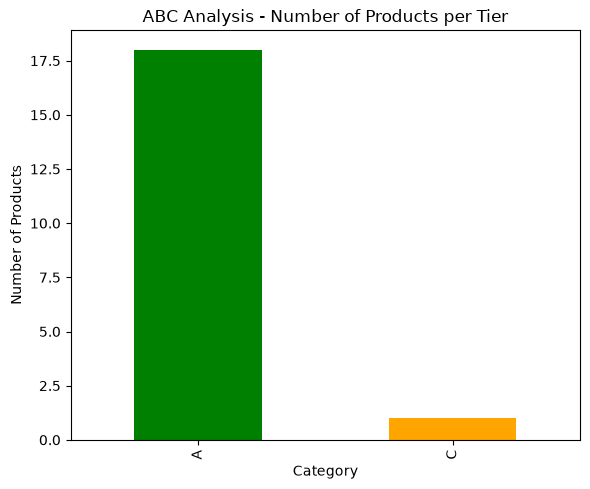

In [31]:
abc_df['Category'].value_counts().sort_index().plot(
    kind='bar', color=['green', 'orange', 'red'], figsize=(6, 5)
)
plt.title('ABC Analysis - Number of Products per Tier')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.show()

In [32]:
abc_df[['Product', 'Revenue Share', 'Cumulative Share', 'Category']]

,Product,Revenue Share,Cumulative Share,Category
0,AAA Batteries (4-pack),0.268814,0.268814,A
1,AA Batteries (4-pack),0.307674,0.576488,A
2,Wired Headphones,0.713997,1.290485,A
3,USB-C Charging Cable,0.829743,2.120228,A
4,Lightning Charging Cable,1.004994,3.125222,A
5,LG Dryer,1.124602,4.249823,A
6,LG Washing Machine,1.159419,5.409242,A
7,20in Monitor,1.316732,6.725974,A
8,Vareebadd Phone,2.400079,9.126053,A
9,27in FHD Monitor,3.281755,12.407808,A


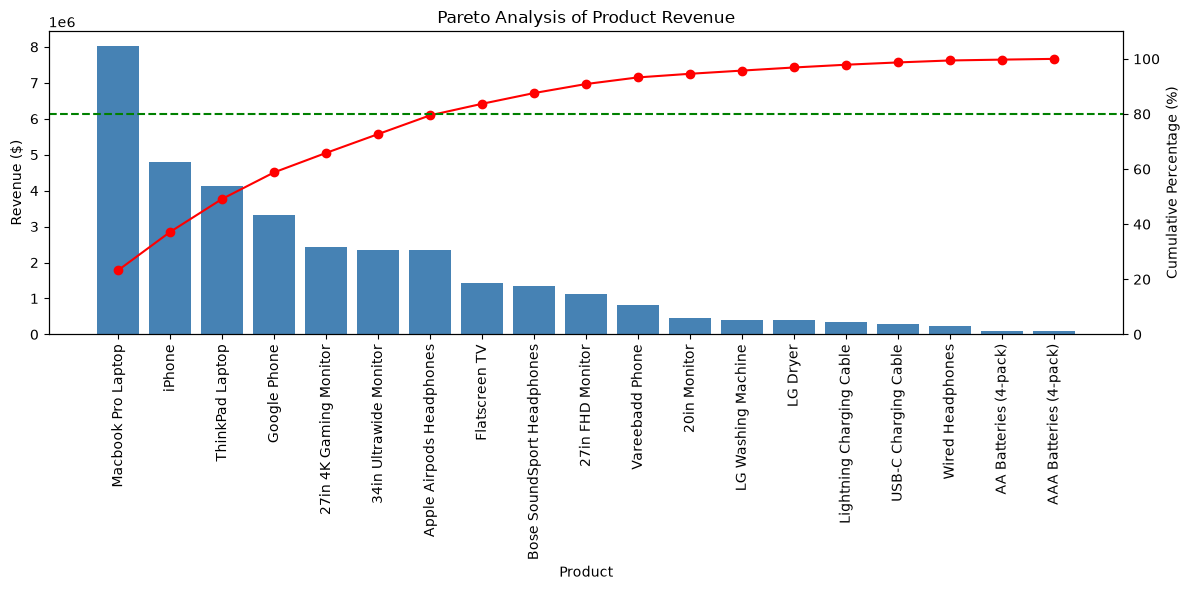

In [33]:
pareto = (
    data.groupby('Product')['Sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
pareto['Cumulative %'] = pareto['Sales'].cumsum() / pareto['Sales'].sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(pareto['Product'], pareto['Sales'], color='steelblue')
ax1.set_xlabel('Product')
ax1.set_ylabel('Revenue ($)')
ax1.tick_params(axis='x', labelrotation=90)

ax2 = ax1.twinx()
ax2.plot(pareto['Product'], pareto['Cumulative %'], color='red', marker='o')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 110)
ax2.axhline(80, color='green', linestyle='--', label='80% threshold')

plt.title('Pareto Analysis of Product Revenue')
plt.tight_layout()
plt.show()

## 9. Key Insights

- **Seasonality:** Sales peak in specific months (see Section 6.1) - useful for planning
  inventory and marketing spend ahead of the busiest period.
- **Geography:** A small number of cities account for a disproportionate share of orders
  (Section 6.2), suggesting where regional marketing or warehousing investment would pay off most.
- **Pricing vs. volume:** Cheaper products consistently sell in far higher volumes than
  premium products (Section 6.3).
- **Timing:** Orders cluster around specific hours of the day (Section 6.5), which can guide
  ad scheduling and staffing.
- **Cross-selling:** Phones are frequently purchased with their matching charging cable
  (Section 7), a clear bundling opportunity.
- **Revenue concentration:** A small set of "A" tier products drives the large majority of
  revenue (Section 8), while "C" tier products contribute comparatively little - candidates
  for promotion, bundling, or discontinuation review.

## 10. Conclusion

This analysis walks through a full sales dataset - from cleaning raw order data to
uncovering *when*, *where*, and *what* customers buy, which products are commonly bought
together, and how revenue is distributed across the product catalog. Together, these
findings could inform inventory planning, marketing timing, regional strategy, and
product bundling decisions.

## 11. Future Improvements

- Add year-over-year comparison if multiple years of data become available
- Build a simple sales forecasting model (e.g. Prophet or ARIMA) on the monthly trend
- Turn the ABC/Pareto and market-basket outputs into an interactive dashboard (e.g. Streamlit or Plotly Dash)
- Add automated data-quality checks (e.g. with `pandera` or `great_expectations`)
- Parameterize the notebook (e.g. with `papermill`) to re-run it on new data drops